### Regression  
   ##### Regression is Supervised machine Technique that is basically used to predict the 
   #### continuous numerical values 

   for example :
    Temp in city       - 30   40   42   20   12   25   45 
    sales of ice cream - 500  700  750  410  250  320  900 

    students 
    study hours  :  10  8   12  5  15  4   6    8  
    Attendance    :  92  85  95  75 89  70  59  78
    Marks Scored : 420 410  430 320 435 300 380 405

    Total 8 rows and 3 cols
### (input )  X - (study hours and Attendance) - Features 
### (output)   Y -(Marks )                     - Response or Labels


### Simple Linear Regression 
in this kind or regression one independent variable predicts the one dpendent variable 

Marks = m* Hours+b 

### Multiple Linear Regression 
    multiple features predicts on value 

    marks=c0 + C1(hours)+C2(Attendace)+C3(previousscore)



In [5]:
import pandas as pd
import numpy as np  
import kagglehub

In [3]:
path=kagglehub.dataset_download("lainguyn123/student-performance-factors")



100%|██████████| 93.9k/93.9k [00:00<00:00, 188kB/s]

Extracting files...


In [10]:
df=pd.read_csv(path+"/StudentPerformanceFactors.csv")
df.head()
df.shape

(6607, 20)

In [11]:
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [14]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [15]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [20]:
df.dropna(inplace=True)
df.shape
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns


In [26]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

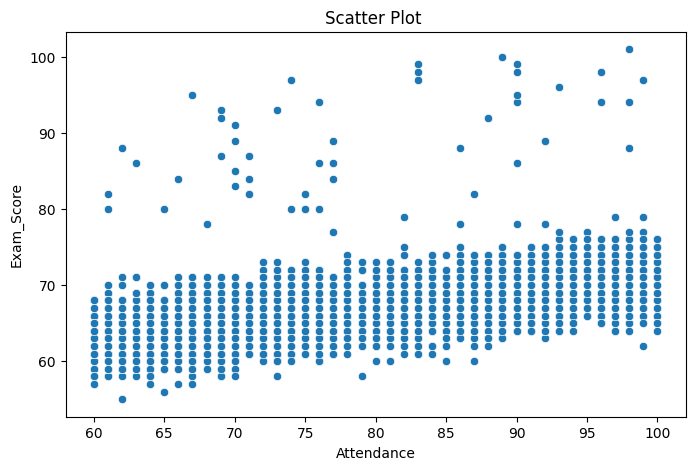

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Hours_Studied",y="Exam_Score",data=df)
plt.title("Scatter Plot ")
plt.show()

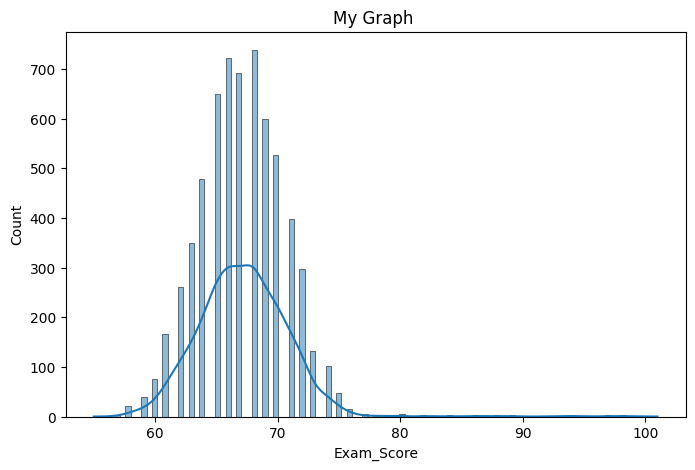

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["Exam_Score"],
             kde=True)
plt.title("My Graph ")
plt.show()

In [32]:
print(df["Exam_Score"].mean())
print(df["Exam_Score"].median())


67.25211665098777
67.0


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [34]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [36]:
## Feature Selection

X=df[["Hours_Studied","Attendance","Previous_Scores"]]
X

,Hours_Studied,Attendance,Previous_Scores
0,23,84,73
1,19,64,59
2,24,98,91
3,29,89,98
4,19,92,65
...,...,...,...
6602,25,69,76
6603,23,76,81
6604,20,90,65
6605,10,86,91


In [39]:
Y=df["Exam_Score"]
Y

0       67
1       61
2       74
3       71
4       70
        ..
6602    68
6603    69
6604    68
6605    68
6606    64
Name: Exam_Score, Length: 6378, dtype: int64

In [43]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=60,test_size=.30)


In [61]:
my_model=LinearRegression()
my_model.fit(X_train,Y_train)

y_pred=my_model.predict(X_test)
acc=r2_score(Y_test,y_pred)
acc*100

50.86782396809406

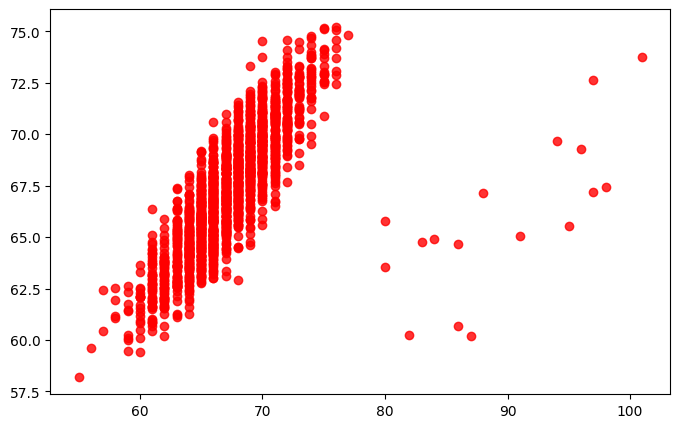

In [64]:
plt.figure(figsize=(8,5))

plt.scatter(Y_test,y_pred,color="red",alpha=0.8)
plt.show()

Introduction to Data Science & Analytics	Data Analytics vs Data Science
	Data Science Lifecycle
	Types of Data Problems
	Industry Roles & Career Paths
	Enterprise Use Cases
	Jupyter Notebook Setup
Numerical Computing with NumPy	NumPy Arrays
	1D & 2D Arrays
	Indexing
	Slicing
	Reshaping
	Broadcasting
Numerical Computing with NumPy & Data Manipulation with Pandas	Vectorization
	Matrix Operations
	Numerical Computations
	Series & DataFrames
	Reading CSV/Excel/JSON Files
Data Manipulation with Pandas	Selecting Rows & Columns
	Filtering
	Sorting
	Exploratory Data Analysis (EDA)
	Missing Values
Data Manipulation with Pandas & Data Wrangling & Feature Engineering	Aggregations
	GroupBy Operations
	Merge
	Join & Concat
	Pivot Tables
Data Wrangling & Feature Engineering	String Processing
	Datetime Handling
	Data Cleaning Techniques
	Feature Engineering Fundamentals
	Handling Missing Values
	Label Encoding
Data Wrangling & Feature Engineering & Statistics for Data Science	One-Hot Encoding
	Feature Scaling
	Time-Series Preprocessing Basics
	Mean
	Median
	Mode
Statistics for Data Science	Variance
	Standard Deviation
	Percentiles
	Quartiles
	Skewness
	Outlier Detection
	Descriptive Statistics Using Python
Probability & Statistical Foundations	Probability Basics
	Conditional Probability
	Sampling Methods
Probability & Statistical Foundations & Hypothesis Testing & Experimentation	Central Limit Theorem
	Normal Distribution
	Null & Alternate Hypothesis
	p-value
	Confidence Intervals
Hypothesis Testing & Experimentation	One-Sample Tests
	Two-Sample Tests
	Chi-Square Test
	ANOVA
	A/B Testing Fundamentals
Data Visualization	Matplotlib Fundamentals
	Seaborn Basics
	Line Plots
	Bar Charts
	Scatter Plots
	Histograms
Data Visualization & Machine Learning Fundamentals	Heatmaps
	Boxplots
	Correlation Visualizations
	Introduction to Machine Learning
	Types of Machine Learning
	ML Workflow
	Features & Target Variables
	Data Preparation Pipeline
Machine Learning Fundamentals & Regression Models	Train-Test Split
	Introduction to Scikit-Learn
	Linear Regression
	Multiple Linear Regression
	Polynomial Regression
	Ridge Regression
Regression Models & Classification Models	Lasso Regression
	MAE
	MSE
	RMSE
	R² Score
	Logistic Regression
Classification Models	K-Nearest Neighbors (KNN)
	Naive Bayes
	Imbalanced Datasets
Classification Models & Model Evaluation & Validation	Precision–Recall Trade-offs
	Confusion Matrix
	Accuracy
	Precision
	Recall
	F1 Score
	ROC Curve
	AUC
	Overfitting & Underfitting
Model Evaluation & Validation & Decision Trees	Bias-Variance Tradeoff
	K-Fold Cross Validation
	Decision Tree Fundamentals
	Entropy
	Gini Impurity
	Information Gain
	Tree Construction
	Tree Depth
Decision Trees & Random Forest	Pruning
	Feature Importance
	Bagging Concepts
	Bootstrap Sampling
	Random Forest Algorithm
	Hyperparameters
	Advantages & Limitations
Ensemble Learning	Bagging vs Boosting
	AdaBoost
	Gradient Boosting
	XGBoost
	LightGBM
	CatBoost Overview
	Grid Search
	Random Search
	Hyperparameter Tuning Concepts